In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
DATA_DIR = "/content/drive/MyDrive/Skin-Lesion-Segmentation/data"
MODEL_PATH = "/content/drive/MyDrive/Skin-Lesion-Segmentation/models/unet_skin_lesion_best.keras"

print("Model exists:", os.path.exists(MODEL_PATH))

Model exists: False


In [4]:
X_test = np.load(
    os.path.join(DATA_DIR, "X_test.npy")
)

Y_test = np.load(
    os.path.join(DATA_DIR, "Y_test.npy")
)

print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_test shape: (90, 256, 256, 3)
Y_test shape: (90, 256, 256, 1)


In [8]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true_f) +
        tf.reduce_sum(y_pred_f) +
        smooth
    )

In [10]:
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_mean(bce) + dice_loss(y_true, y_pred)

In [13]:
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "dice_coefficient": dice_coefficient,
        "dice_loss": dice_loss,
        "combined_loss": combined_loss
    }
)

print("Best model loaded successfully!")

Best model loaded successfully!


In [14]:
Y_pred_prob = model.predict(
    X_test,
    batch_size=8,
    verbose=1
)

print("Prediction shape:", Y_pred_prob.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 193s 16s/step
Prediction shape: (90, 256, 256, 1)


In [28]:
Y_pred = (Y_pred_prob >= 0.5).astype(np.float32)

In [29]:
def dice_score(y_true, y_pred, smooth=1e-6):
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)

    intersection = np.sum(y_true * y_pred)

    return (
        2 * intersection + smooth
    ) / (
        np.sum(y_true) + np.sum(y_pred) + smooth
    )


def iou_score(y_true, y_pred, smooth=1e-6):
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)

    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection

    return (intersection + smooth) / (union + smooth)

In [30]:
dice_scores = []
iou_scores = []

for i in range(len(X_test)):
    dice_scores.append(
        dice_score(Y_test[i], Y_pred[i])
    )

    iou_scores.append(
        iou_score(Y_test[i], Y_pred[i])
    )

mean_dice = np.mean(dice_scores)
mean_iou = np.mean(iou_scores)

print("Mean Dice:", mean_dice)
print("Mean IoU:", mean_iou)

Mean Dice: 0.78753406
Mean IoU: 0.6871654


In [31]:
y_true_flat = Y_test.reshape(-1)
y_pred_flat = Y_pred.reshape(-1)

precision = precision_score(
    y_true_flat,
    y_pred_flat,
    zero_division=0
)

recall = recall_score(
    y_true_flat,
    y_pred_flat,
    zero_division=0
)

accuracy = accuracy_score(
    y_true_flat,
    y_pred_flat
)

print("Precision:", precision)
print("Recall:", recall)
print("Pixel Accuracy:", accuracy)

Precision: 0.8244137908486938
Recall: 0.7582811992938255
Pixel Accuracy: 0.8908789740668402


In [32]:
metrics = {
    "Dice": mean_dice,
    "IoU": mean_iou,
    "Precision": precision,
    "Recall": recall,
    "Pixel Accuracy": accuracy
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Dice: 0.7875
IoU: 0.6872
Precision: 0.8244
Recall: 0.7583
Pixel Accuracy: 0.8909


In [33]:
def visualize_prediction(index):
    image = X_test[index]
    true_mask = Y_test[index].squeeze()
    pred_mask = Y_pred[index].squeeze()

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(true_mask, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(image)
    plt.imshow(pred_mask, alpha=0.4, cmap="Reds")
    plt.title("Prediction Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

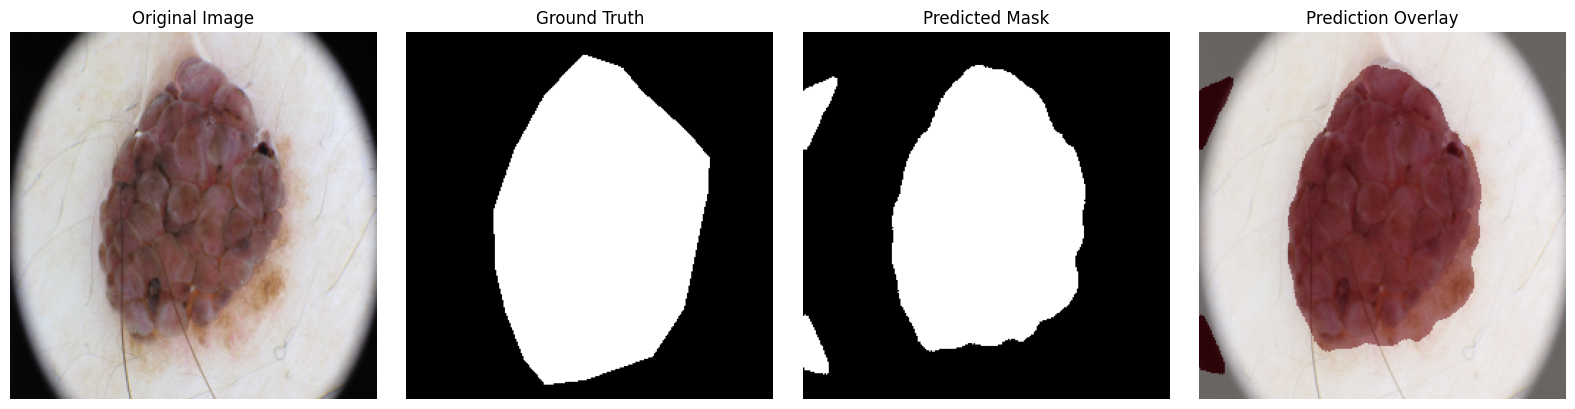

In [34]:
visualize_prediction(0)

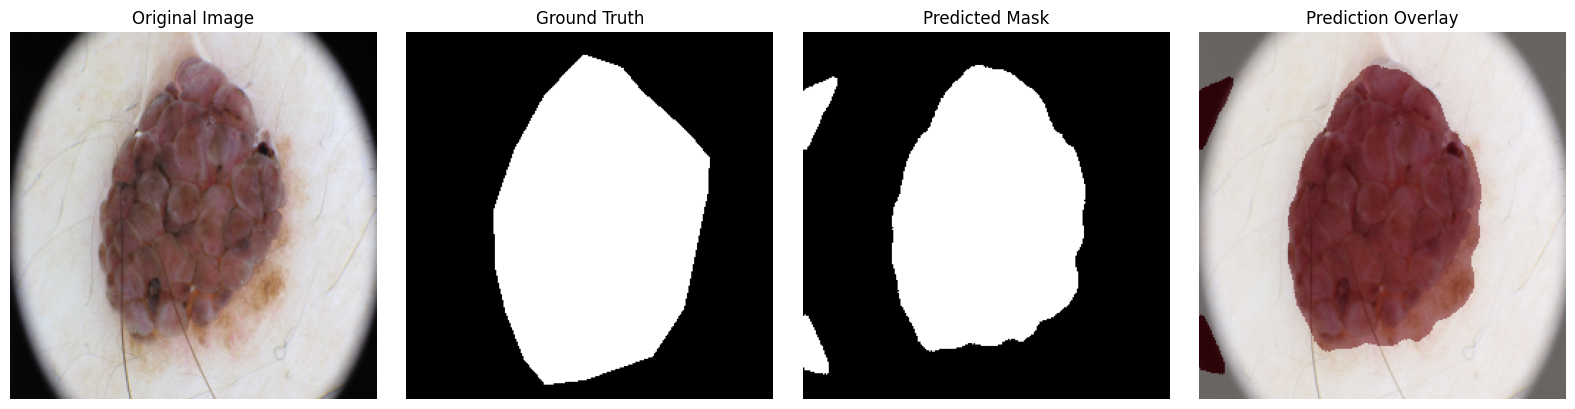

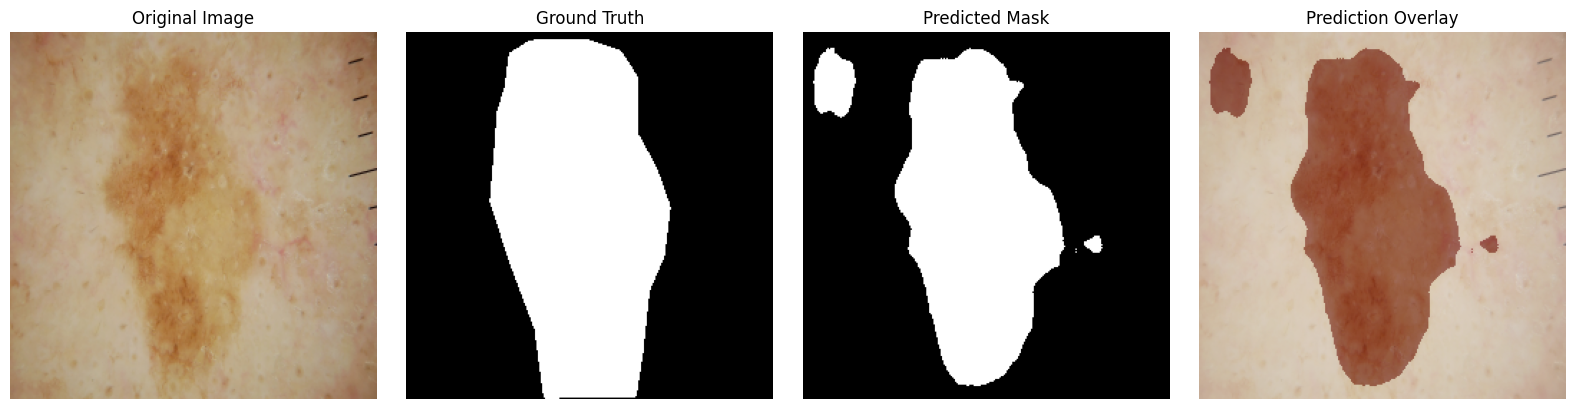

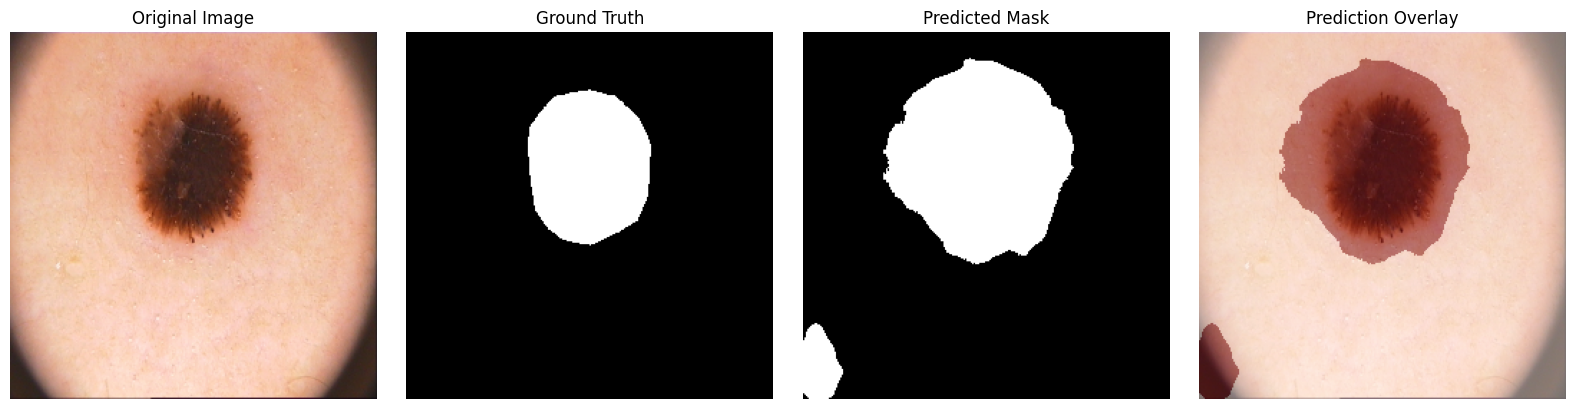

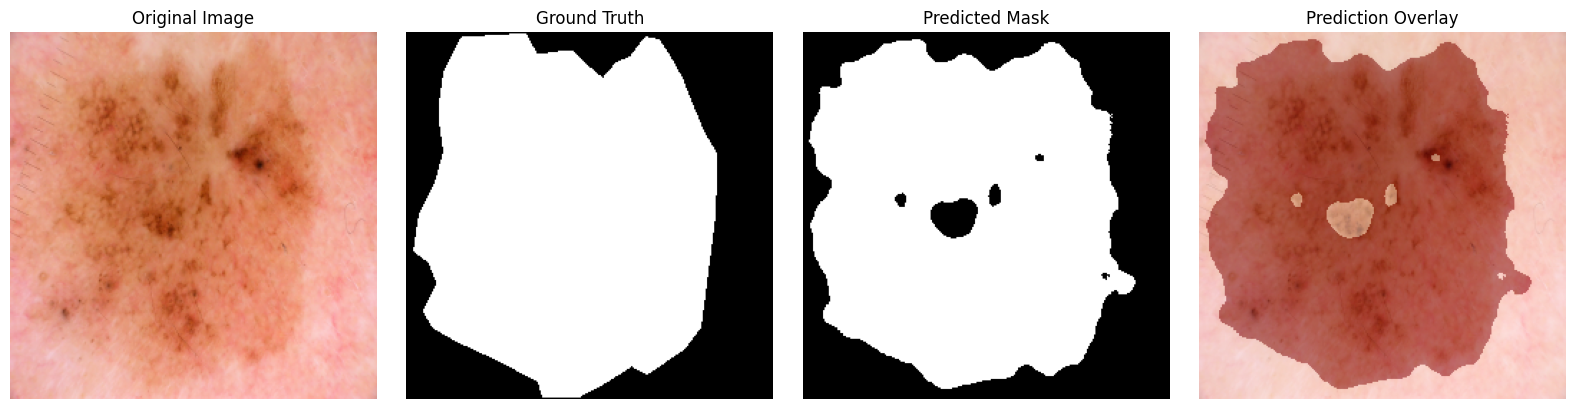

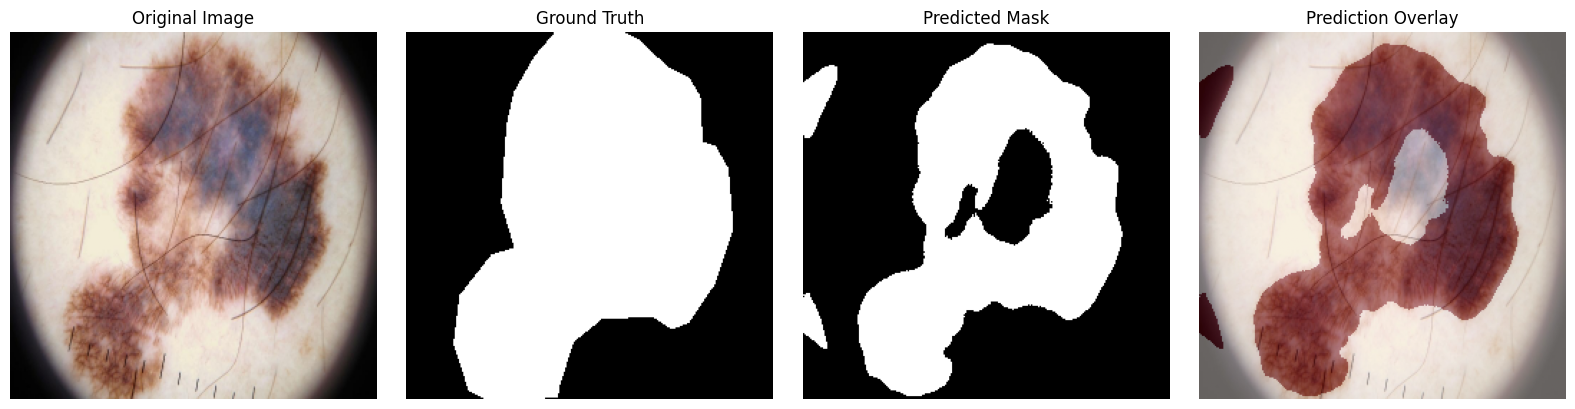

In [23]:
for i in [0, 10, 20, 30, 40]:
    visualize_prediction(i)

In [24]:
best_indices = np.argsort(dice_scores)[-3:]
worst_indices = np.argsort(dice_scores)[:3]

print("Best prediction indices:", best_indices)
print("Worst prediction indices:", worst_indices)

Best prediction indices: [64 16 80]
Worst prediction indices: [67 34 18]


Dice: 0.9731


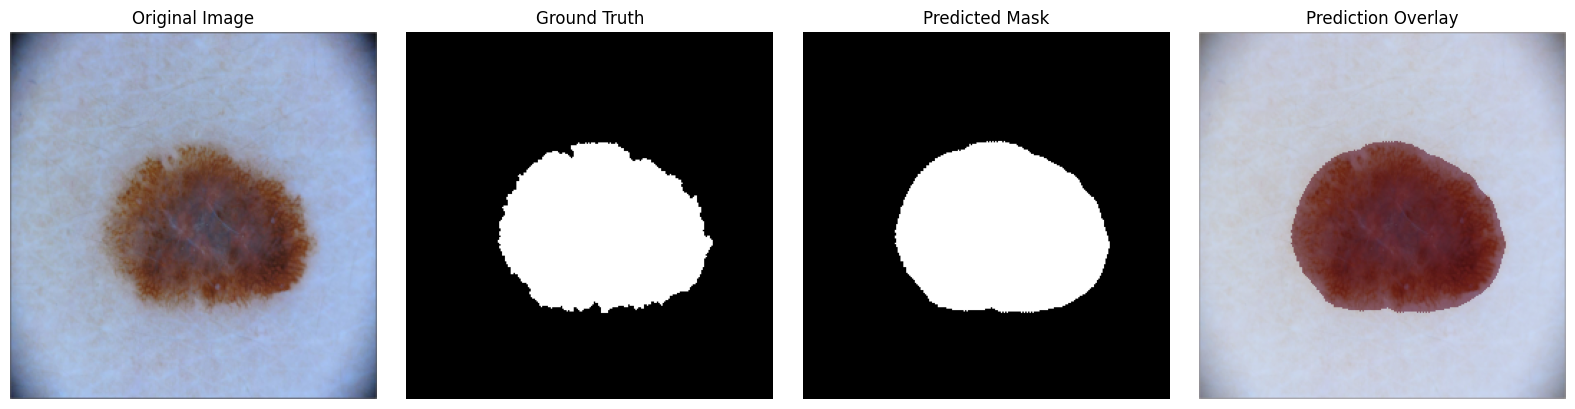

Dice: 0.9768


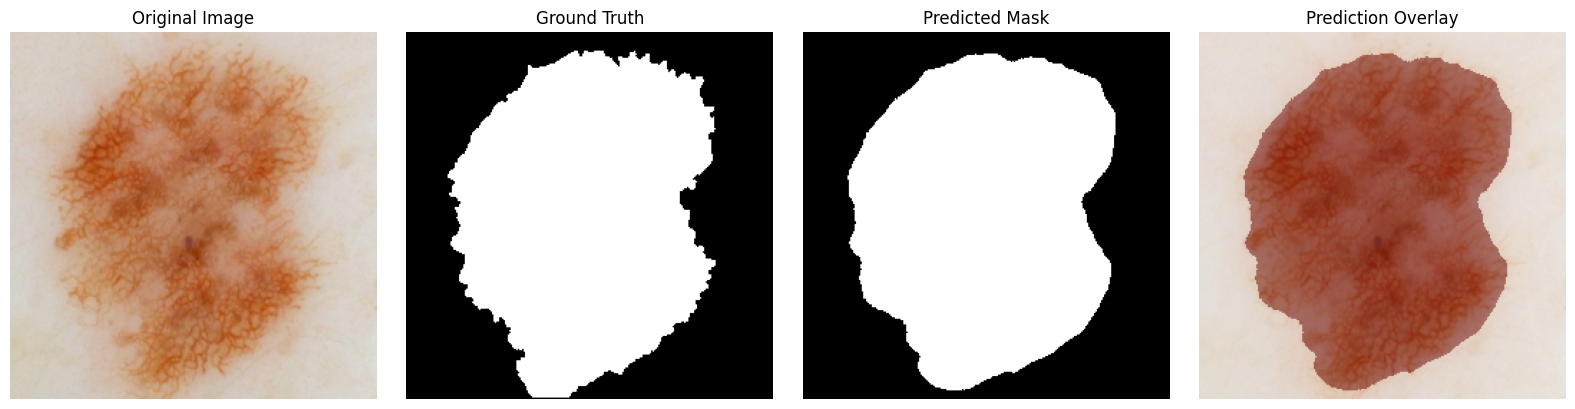

Dice: 0.9850


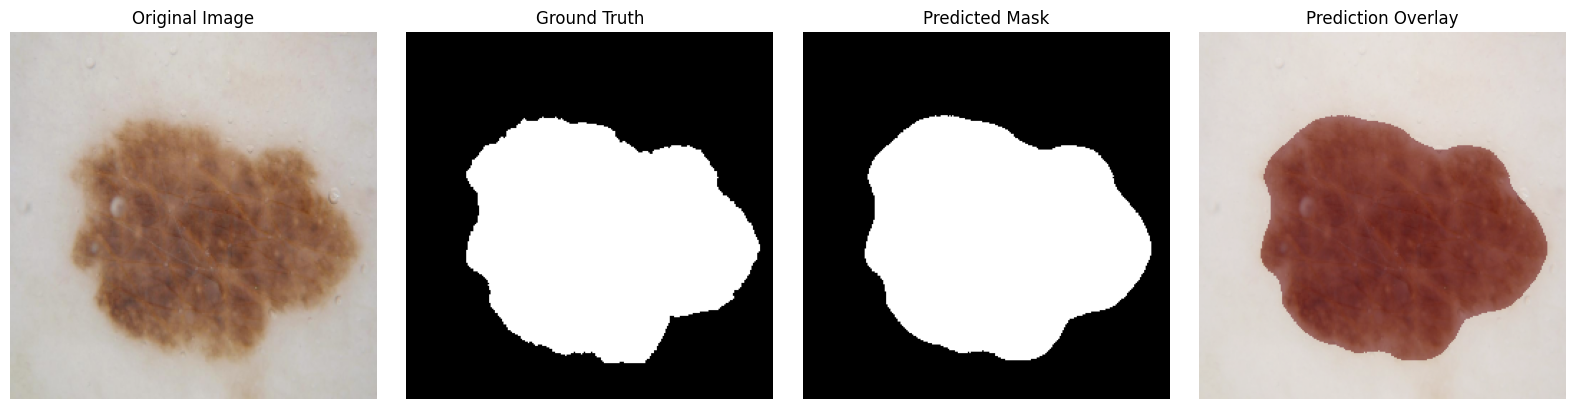

In [25]:
for i in best_indices:
    print(f"Dice: {dice_scores[i]:.4f}")
    visualize_prediction(i)

Dice: 0.0000


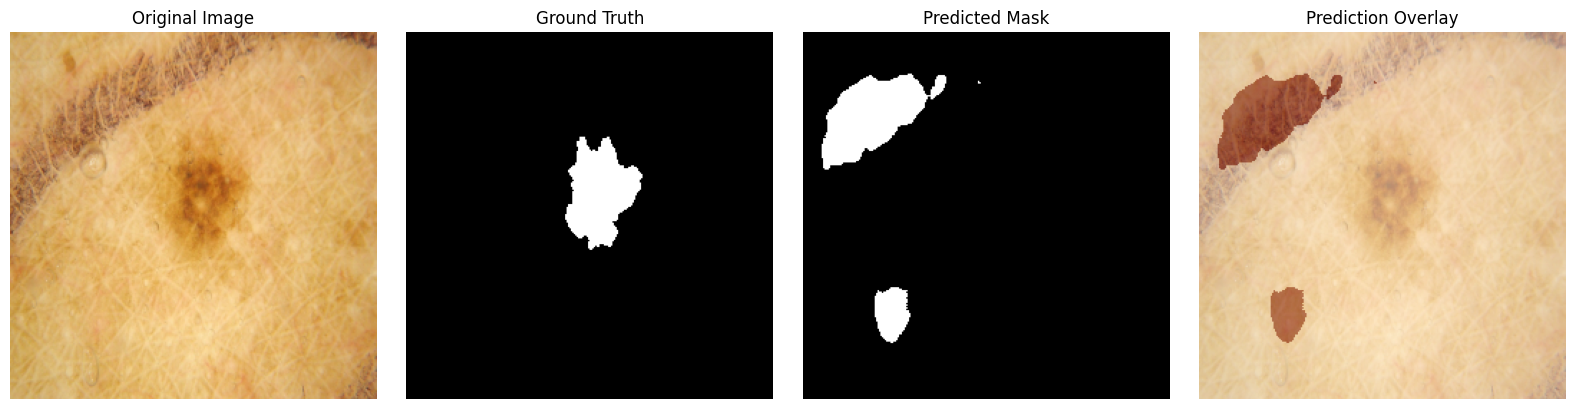

Dice: 0.0662


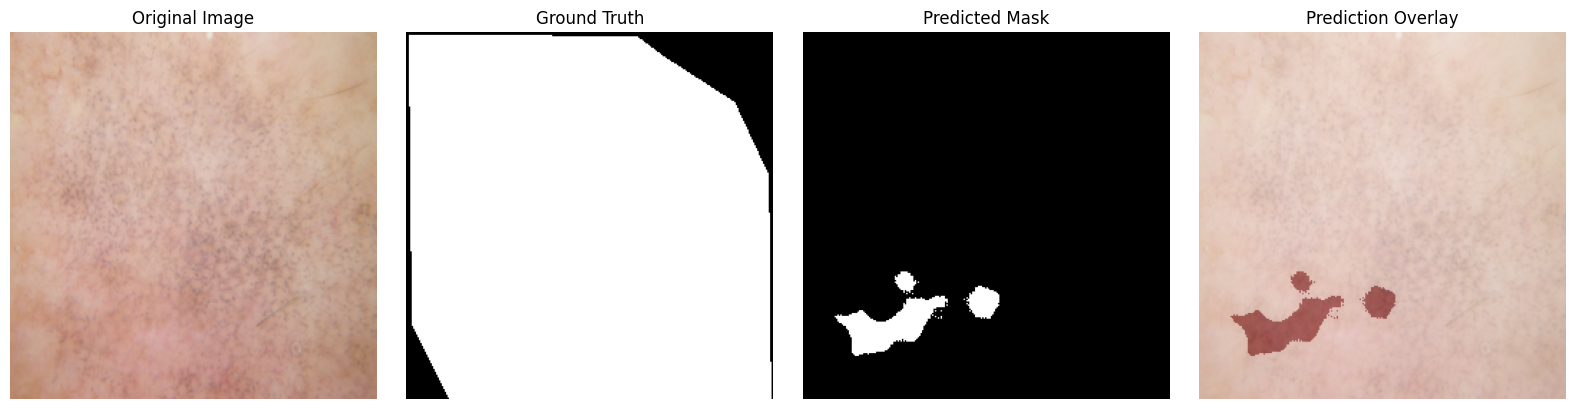

Dice: 0.2072


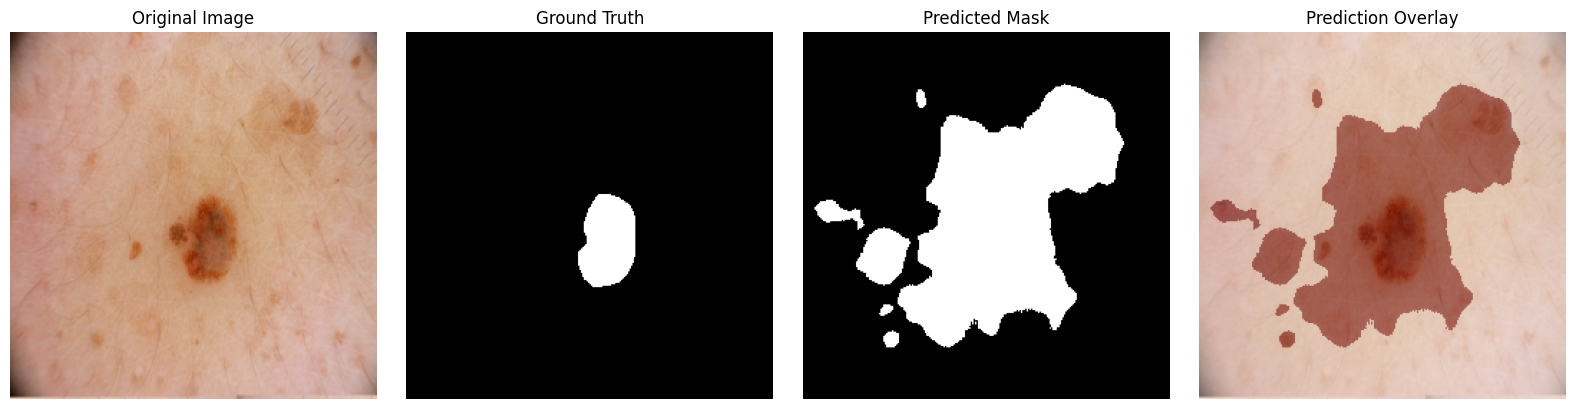

In [26]:
for i in worst_indices:
    print(f"Dice: {dice_scores[i]:.4f}")
    visualize_prediction(i)

In [27]:
results = {
    "dice": mean_dice,
    "iou": mean_iou,
    "precision": precision,
    "recall": recall,
    "pixel_accuracy": accuracy
}

np.save(
    "/content/drive/MyDrive/Skin-Lesion-Segmentation/evaluation_results.npy",
    results
)

## Error Analysis and Limitations

* The qualitative results show that the model performs well on many lesions with clear boundaries and sufficient contrast from the surrounding skin.

* However, performance decreases for challenging cases. Some images contain low-contrast lesions, small lesion regions, irregular boundaries, or image artifacts. These factors can lead to false-positive regions, missed lesion pixels, or inaccurate boundaries.

* For example, some low-Dice cases show the model predicting regions outside the ground-truth lesion or failing to capture the complete lesion area. This demonstrates that although the U-Net learns the general spatial characteristics of skin lesions, further improvements are possible through data augmentation, a larger training set, stronger regularization, and more advanced segmentation architectures.

* The evaluation therefore considers both quantitative metrics and qualitative visualization rather than relying on pixel accuracy alone.

## Conclusion

* A U-Net based semantic segmentation model was developed to identify and segment skin lesions from dermoscopic images using the ISIC 2016 lesion segmentation dataset.

* The best available checkpoint achieved a validation Dice coefficient of 0.7641 and obtained a test Dice coefficient of 0.7875 and IoU of 0.6872 on 90 held-out test images.

* The qualitative results demonstrate that the model can successfully capture the approximate lesion region in many cases, while failure cases highlight challenges associated with low contrast, small lesions, irregular boundaries, and image artifacts.

* Overall, the project demonstrates an end-to-end medical image segmentation workflow covering data preprocessing, U-Net architecture design, custom segmentation loss, model training, quantitative evaluation, and qualitative error analysis.